<a href="https://colab.research.google.com/github/gustavoofarias/Fundamentos-de-Linguagem-Python-Para-An-lise-de-Dados-e-Data-Science/blob/main/Projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para o Projeto 2 o objetivo é responder10 perguntas de negócio a partir de um dataset sobre uma rede de varejo que comercializa diversos produtos em diversas cidades dos EUA.Os dados são reais e foram extraídos do link abaixo:https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxlsFizemos algumas simplificações no dataset e entregaremos o arquivo a você em formato CSV junto com os demais arquivos do capítulo.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carregando o arquivo Excel corretamente usando Pandas
df = pd.read_excel('/content/Sample - Superstore.xls')

# Exibindo as primeiras linhas do DataFrame para verificar se foi carregado corretamente
print(df.head())
# Verificando Valores Nulos
print(df.isnull().sum())
print(df.describe())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

•Pergunta de Negócio 1:Qual Cidade com Maior Valor de Venda de Produtos da Categoria 'Office Supplies'?

In [4]:


# Criar uma conexão com o banco de dados SQLite
conn = sqlite3.connect(':memory:')  # Banco de dados temporário na memória

# Carregar o arquivo Excel para um DataFrame
df = pd.read_excel('/content/Sample - Superstore.xls')

# Salvar o DataFrame no banco de dados SQLite
df.to_sql('tabela_excel', conn, index=False)

# Consulta SQL
query = "SELECT  City, max(Sales) FROM tabela_excel WHERE Category = 'Office Supplies' GROUP BY Category, City  ORDER BY max(Sales) DESC"

# Executar a consulta SQL e obter o resultado como DataFrame
resultado = pd.read_sql_query(query, conn)

# Exibir o resultado
print(resultado)

print("A cidade com maior valor é Detroit")


              City  max(Sales)
0          Detroit    9892.740
1      Minneapolis    9449.950
2    San Francisco    8187.650
3          Atlanta    6354.950
4          Jackson    5443.960
..             ...         ...
479   Ormond Beach       2.808
480      Pensacola       2.214
481        Jupiter       2.064
482         Elyria       1.824
483        Abilene       1.392

[484 rows x 2 columns]
A cidade com maior valor é Detroit


•Pergunta de Negócio 2:Qual o Total de Vendas Por Data do Pedido?Demonstre o resultado através de um gráfico de barras.

<function matplotlib.pyplot.show(close=None, block=None)>

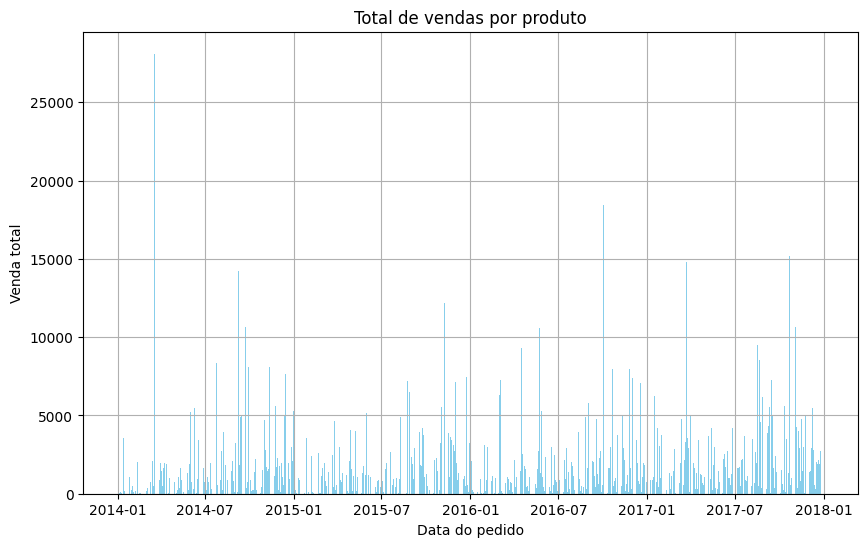

In [5]:
# Consulta
query2 = "SELECT [Order Date], SUM(Sales) as TotalSales FROM tabela_excel GROUP BY [Order Date] "
# Executar a Consulta SQL
resultado2 = pd.read_sql_query(query2, conn)

# Convertendo a coluna para o formato de datetime
resultado2['Order Date'] = pd.to_datetime(resultado2['Order Date'])

# Plotando o Gráfico

plt.figure(figsize=(10,6))
plt.bar(resultado2['Order Date'], resultado2['TotalSales'], color= 'skyblue')

# Colocando legenda e titulo

plt.title('Total de vendas por produto')
plt.xlabel('Data do pedido')
plt.ylabel('Venda total')
plt.grid()



plt.show


Pergunta de Negócio 3:
Qual o Total de Vendas por Estado?
Demonstre o resultado através de um gráfico de barras.

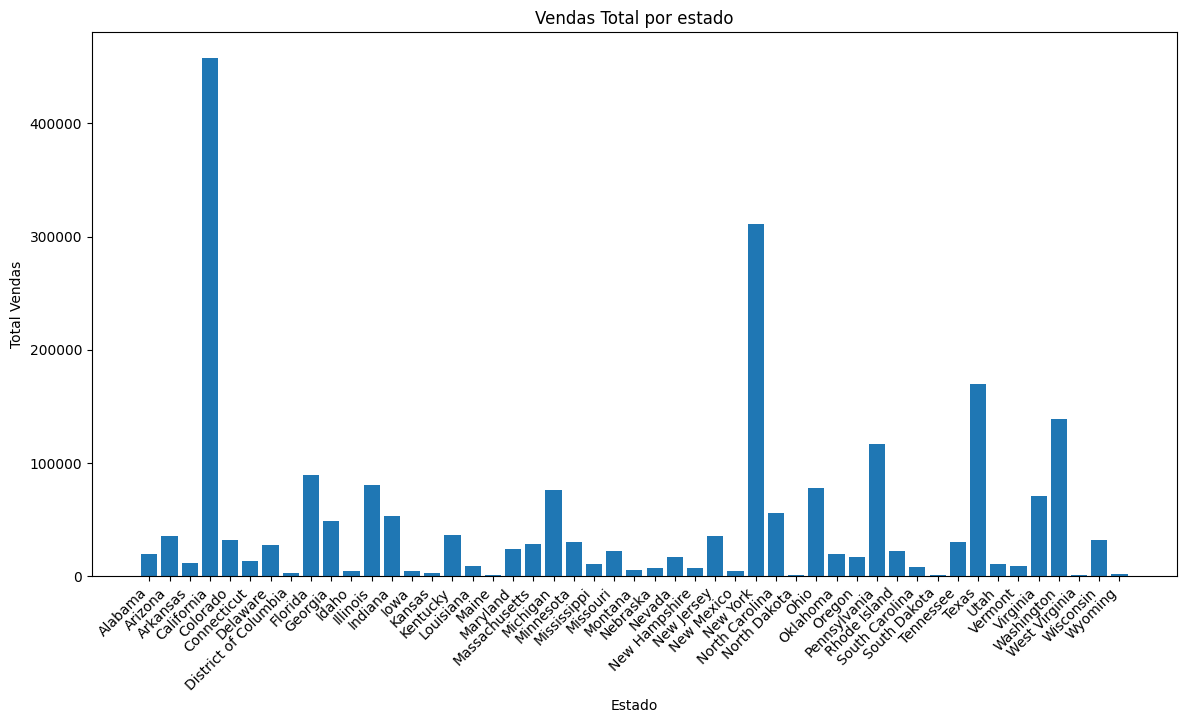

In [6]:
# Consulta

query3 = "SELECT State, SUM(Sales) as [Total Vendas] FROM tabela_excel GROUP BY State "

# Executar a consulta SQL
resultado3 = pd.read_sql_query(query3, conn)

# Plotando o Gráfico

plt.figure(figsize=(14,8))
plt.bar(resultado3['State'], resultado3['Total Vendas'])

# Colocando Titulo e legenda
plt.title('Vendas Total por estado')
plt.xlabel('Estado')
plt.ylabel('Total Vendas')
# Ajustando o Gráfico

plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.show()


Pergunta de Negócio 4:Quais São as 10 Cidades com Maior Total de Vendas?Demonstre o resultado através de um gráfico de barras

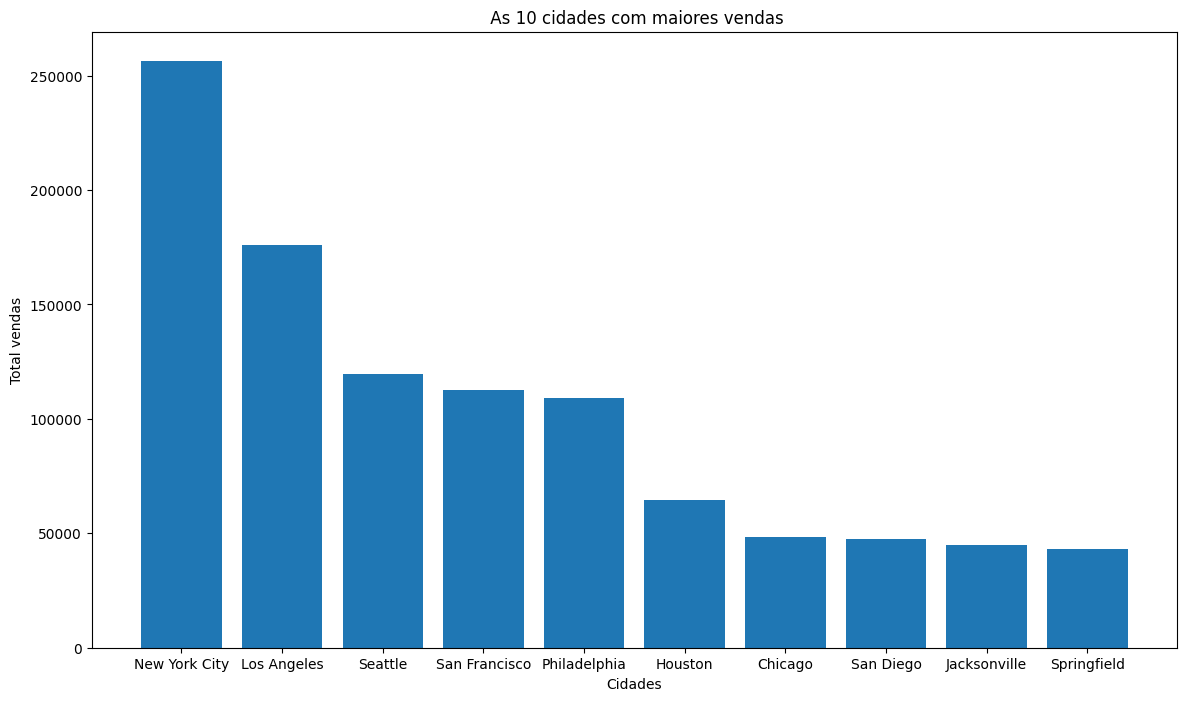

In [22]:

# Consulta SQL
query4 = "SELECT  City as Cidade, SUM(Sales) as [Total Vendas]  FROM tabela_excel GROUP BY City ORDER BY [Total vendas] DESC LIMIT 10"

# Executando a consulta

resultado4 = pd.read_sql_query(query4, conn)

#Plotando o gráfico

plt.figure(figsize= (14,8))
plt.bar(resultado4['Cidade'], resultado4['Total Vendas'])

# Colocando Titulo e Legenda

plt.title(" As 10 cidades com maiores vendas")
plt.xlabel('Cidades')
plt.ylabel('Total vendas')


plt.show()


Pergunta de Negócio 5:Qual Segmento Teve o Maior Total de Vendas?Demonstre o resultado através de um gráfico de pizza

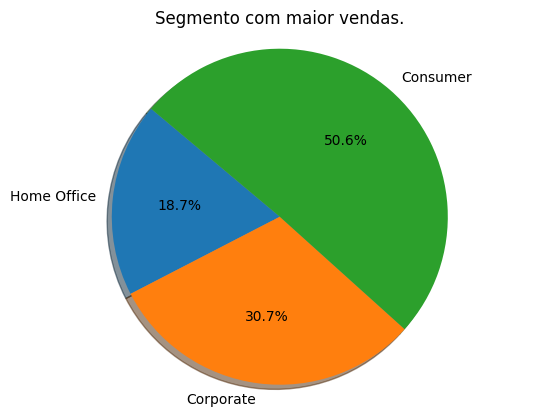

In [30]:

# Consulta SQL

query5 = '''

SELECT Segment, SUM(Sales) as [Total Sales]

FROM tabela_excel

GROUP BY Segment

ORDER BY [Total Sales]
'''

# Executando a consultado
resultado5 = pd.read_sql_query(query5, conn)



# Plotar o gráfico de pizza

plt.pie(resultado5['Total Sales'], labels=resultado5['Segment'], autopct='%1.1f%%', startangle=140, shadow= True)

# Garantir que o gráfico seja plotado como um círculo
plt.axis('equal')

# Colocando titulo
plt.title("Segmento com maior vendas.")

# Mostrar gráfico
plt.show()



•Pergunta de Negócio 6 (Desafio Nível Baby):Qual o Total de Vendas Por Segmento e Por Ano?


In [38]:
query6 = '''
SELECT Segment, strftime('%Y', [Order Date]) as Ano, SUM(Sales) as [Total Vendas]
FROM tabela_excel
GROUP BY Segment, strftime('%Y', [Order Date])
'''

resultado6 = pd.read_sql_query(query6, conn)

print(resultado6)


        Segment   Ano  Total Vendas
0      Consumer  2014   266096.8126
1      Consumer  2015   266535.9333
2      Consumer  2016   296863.8992
3      Consumer  2017   331904.6999
4     Corporate  2014   128434.8737
5     Corporate  2015   128757.3069
6     Corporate  2016   207106.3618
7     Corporate  2017   241847.8244
8   Home Office  2014    89715.8118
9   Home Office  2015    75239.2688
10  Home Office  2016   105235.3370
11  Home Office  2017   159462.7309


DESAFIO 7: Os  gestores  da  empresa  estão  considerando conceder  diferentes  faixas  de  descontos  e gostariam de fazer uma simulação com base na regra abaixo:Se o Valor_Venda for maior que 1000 recebe 15% de desconto.Se o Valor_Venda for menor que 1000 recebe 10% de desconto.Quantas Vendas Receberiam 15% de Desconto?